## A notebook to visualize SenNet biomarker data

In [1]:
# Install and import packages
%pip install pandas seaborn matplotlib scikit-learn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached scipy-1.15.2-cp312-cp312-win_amd64.whl (40.9 MB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [3]:
# Load sample dataset

df = pd.read_csv(
    "data/CU034-U54-HRA-058-A_coords_scores.csv")

df

,barcode,x,y,San.Diego.TMC,Resistance.to.Apoptosis,Fridman,Activated.p53.Targets,DDR,SASP,Cell.Cycle.Arrest,Senmayo
0,AAACAACGAATAGTTC-1,3590,1281,-0.028666,-0.062678,0.156891,-0.056996,-0.037538,-0.016545,0.185525,-0.061099
1,AAACAAGTATCTCCCA-1,13307,11111,-0.053088,0.210114,0.035705,-0.050288,-0.030781,0.031370,-0.148785,-0.140747
2,AAACAATCTACTAGCA-1,6641,1871,-0.080499,-0.051282,0.161620,-0.076238,-0.030781,0.001510,-0.149464,-0.095209
3,AAACACCAATAACTGC-1,3929,12881,-0.025482,-0.008547,0.021632,-0.014578,0.188438,-0.037329,0.045675,-0.035429
4,AAACAGAGCGACTCCT-1,12403,4034,0.005929,-0.017094,0.025354,-0.059214,0.058746,-0.003351,-0.015797,-0.022505
...,...,...,...,...,...,...,...,...,...,...,...
4987,TTGTTTCACATCCAGG-1,6528,12684,-0.076314,-0.074074,0.018957,-0.066200,0.008071,0.010723,-0.106612,-0.119121
4988,TTGTTTCATTAGTCTA-1,5172,13077,-0.014153,-0.011396,0.021671,0.007124,-0.013514,-0.010683,-0.027162,-0.026813
4989,TTGTTTCCATACAACT-1,4833,10128,-0.041268,-0.031339,-0.021981,-0.011972,0.035098,-0.020243,0.027734,-0.050374
4990,TTGTTTGTATTACACG-1,6415,15633,-0.002236,-0.002849,0.003179,-0.000827,-0.003378,-0.004473,-0.007148,-0.009670


In [4]:
# get largest mean between markers/hallmarks
df['mean'] = df.iloc[:, 3:10].mean(axis=1)

# add new columns for variance and standard deviation
df['variance'] = df.iloc[:, 3:10].var(axis=1)
df['stdev'] = df.iloc[:, 3:10].std(axis=1)

# threshold data to only keep extremes
df['meets_thresholds'] = ((df['variance'] < 0.05) & (df['mean'] > .05))

# show new columns
df[df['meets_thresholds'] == True]

,barcode,x,y,San.Diego.TMC,Resistance.to.Apoptosis,Fridman,Activated.p53.Targets,DDR,SASP,Cell.Cycle.Arrest,Senmayo,mean,variance,stdev,meets_thresholds
12,AAACCGGAAATGTTAA-1,15793,11898,0.009690,-0.059829,0.407753,-0.056622,0.211712,0.013032,-0.104432,0.000967,0.060186,0.033947,0.184248,True
27,AAACTAACGTGGCGAC-1,14211,2854,0.003659,-0.042735,0.289087,-0.079665,0.144520,-0.025362,0.111330,-0.022242,0.057262,0.017121,0.130849,True
94,AACATCGATACGTCTA-1,14550,4623,0.071593,-0.031339,0.517271,-0.113061,0.009760,0.059251,0.079164,0.069275,0.084663,0.041026,0.202550,True
135,AACGTGATGAAGGACA-1,11160,3051,-0.023703,0.207265,0.152200,-0.023270,0.171547,-0.035472,-0.082952,-0.081846,0.052231,0.014283,0.119512,True
142,AACTCAAGTTAATTGC-1,6754,8752,-0.099055,0.187322,0.142431,-0.074137,0.203266,-0.036465,0.034096,-0.113231,0.051065,0.016040,0.126649,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4910,TTGCAGGTCATGAAGT-1,13759,1281,0.025038,0.224359,0.100291,-0.000315,0.035098,-0.013460,0.043495,-0.019868,0.059215,0.006630,0.081427,True
4953,TTGGGACGTAAGAGTT-1,14098,11308,0.037475,-0.025641,0.311882,-0.031632,0.051989,-0.006145,0.025625,-0.009407,0.051936,0.014141,0.118918,True
4958,TTGGTGCGGTGTTGAA-1,15567,2461,-0.005414,-0.019943,0.141035,-0.043801,0.181682,0.033219,0.086383,-0.006242,0.053309,0.007320,0.085555,True
4978,TTGTGGTATAGGTATG-1,16019,6000,0.017224,0.204416,0.162473,-0.053796,0.048611,0.042917,0.037062,0.066286,0.065558,0.007811,0.088381,True


## Plot by mean and variance to identify cells with high mean and low variance

C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_43544\1636037061.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df[plot_on_x], df[plot_on_y], alpha=alpha_mapped, color = colors_mapped, cmap='inferno', s=3)


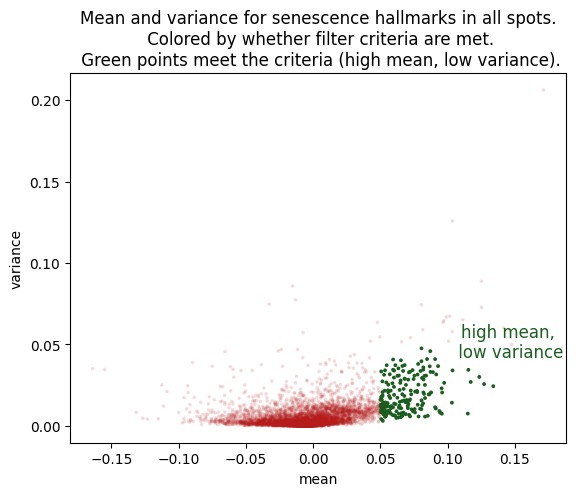

In [5]:
# draw scatter graph of mean vs variance with thresholds
plot_on_x = 'mean'
plot_on_y = 'variance'

# set colors based on thresholds
alpha_mapped = df['meets_thresholds'].map({True: 1, False: 0.1})
colors_mapped = df['meets_thresholds'].map({True: "#1B5E20", False: "#B71C1C"})

plt.figure()
plt.scatter(df[plot_on_x], df[plot_on_y], alpha=alpha_mapped, color = colors_mapped, cmap='inferno', s=3)
plt.title(f'Mean and variance for senescence hallmarks in all spots.\n Colored by whether filter criteria are met.\n Green points meet the criteria (high mean, low variance).')
plt.xlabel(plot_on_x)
plt.ylabel(plot_on_y)

# add text to call out extreme measurements
# Adding labels at specific (x, y) coordinates
plt.text(x=.145, y=.042, s='high mean,\n low variance',
         fontsize=12, ha='center', color='#1B5E20')


plt.show()

In [6]:
# export to CSV
df.to_csv("data/CU034-U54-HRA-058-A_coords_scores_with_thresholds.csv", index=False)

In [7]:
# To normalize variance, initialize MinMaxScaler
scaler = MinMaxScaler((0,1))

# Fit and transform the column
df['variance_norm'] = scaler.fit_transform(df[['variance']])
df

,barcode,x,y,San.Diego.TMC,Resistance.to.Apoptosis,Fridman,Activated.p53.Targets,DDR,SASP,Cell.Cycle.Arrest,Senmayo,mean,variance,stdev,meets_thresholds,variance_norm
0,AAACAACGAATAGTTC-1,3590,1281,-0.028666,-0.062678,0.156891,-0.056996,-0.037538,-0.016545,0.185525,-0.061099,0.019999,0.010986,0.104814,False,0.053263
1,AAACAAGTATCTCCCA-1,13307,11111,-0.053088,0.210114,0.035705,-0.050288,-0.030781,0.031370,-0.148785,-0.140747,-0.000822,0.012472,0.111679,False,0.060469
2,AAACAATCTACTAGCA-1,6641,1871,-0.080499,-0.051282,0.161620,-0.076238,-0.030781,0.001510,-0.149464,-0.095209,-0.032162,0.009515,0.097546,False,0.046133
3,AAACACCAATAACTGC-1,3929,12881,-0.025482,-0.008547,0.021632,-0.014578,0.188438,-0.037329,0.045675,-0.035429,0.024259,0.006045,0.077752,False,0.029310
4,AAACAGAGCGACTCCT-1,12403,4034,0.005929,-0.017094,0.025354,-0.059214,0.058746,-0.003351,-0.015797,-0.022505,-0.000775,0.001364,0.036933,False,0.006613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4987,TTGTTTCACATCCAGG-1,6528,12684,-0.076314,-0.074074,0.018957,-0.066200,0.008071,0.010723,-0.106612,-0.119121,-0.040778,0.002660,0.051573,False,0.012895
4988,TTGTTTCATTAGTCTA-1,5172,13077,-0.014153,-0.011396,0.021671,0.007124,-0.013514,-0.010683,-0.027162,-0.026813,-0.006873,0.000259,0.016096,False,0.001256
4989,TTGTTTCCATACAACT-1,4833,10128,-0.041268,-0.031339,-0.021981,-0.011972,0.035098,-0.020243,0.027734,-0.050374,-0.009139,0.000856,0.029263,False,0.004152
4990,TTGTTTGTATTACACG-1,6415,15633,-0.002236,-0.002849,0.003179,-0.000827,-0.003378,-0.004473,-0.007148,-0.009670,-0.002533,0.000010,0.003202,False,0.000050


C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_43544\283933213.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df['x'], df['y'], c=colors_mapped, cmap='inferno', alpha=alpha_mapped, s=3)


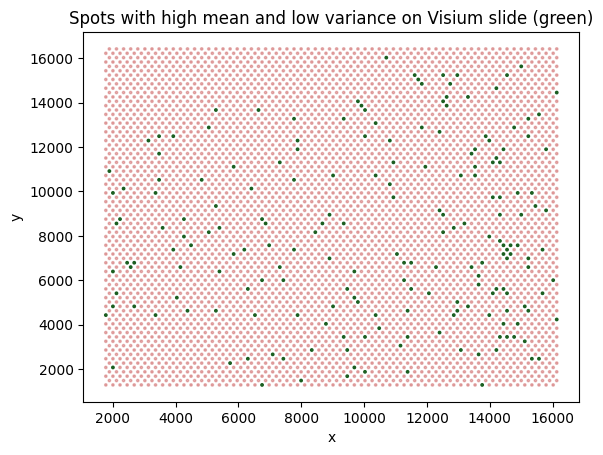

In [8]:
alpha_mapped = df['meets_thresholds'].map({True: 1, False: 0.3})
colors_mapped = df['meets_thresholds'].map({True: "#1B5E20", False: "#B71C1C"})


# plot each B with mean and var
plt.figure()
plt.scatter(df['x'], df['y'], c=colors_mapped, cmap='inferno', alpha=alpha_mapped, s=3)
plt.title(f'Spots with high mean and low variance on Visium slide (green)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Plot by biomarker

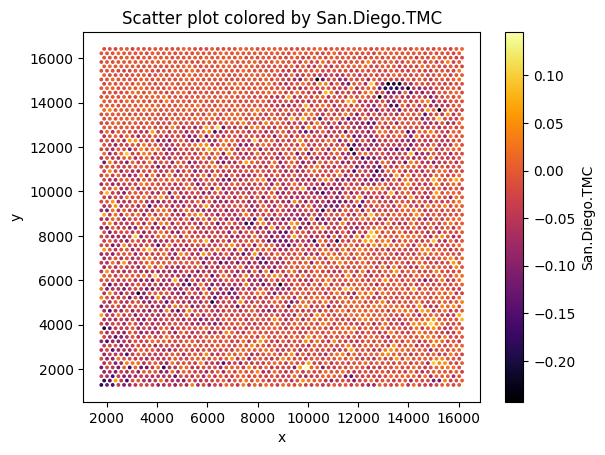

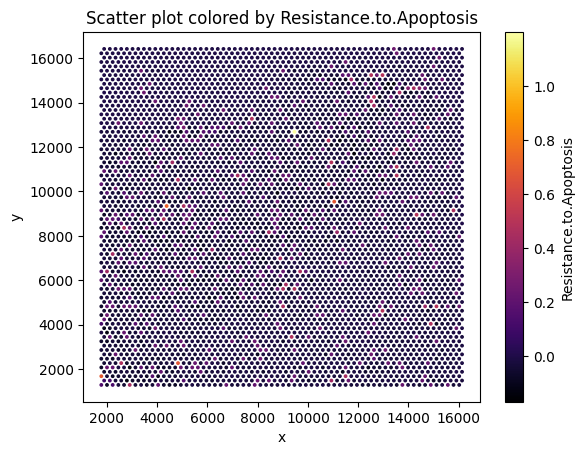

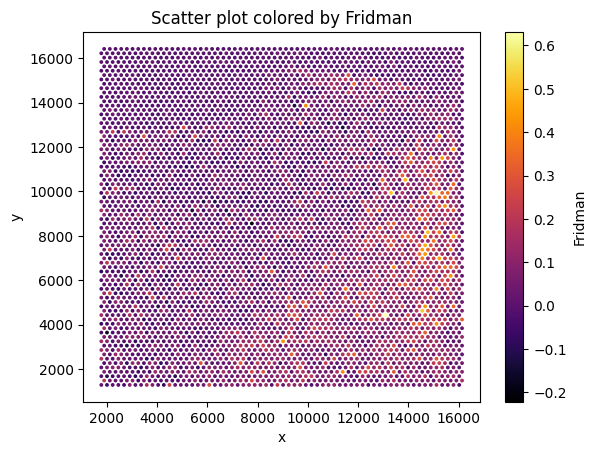

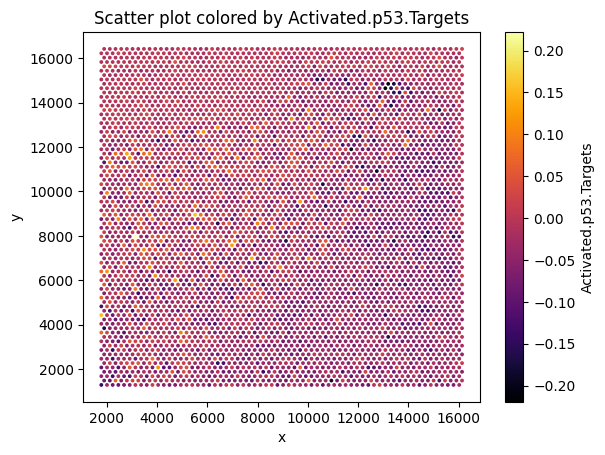

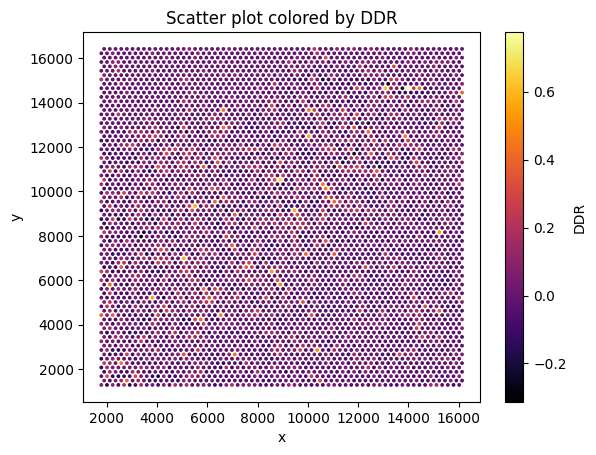

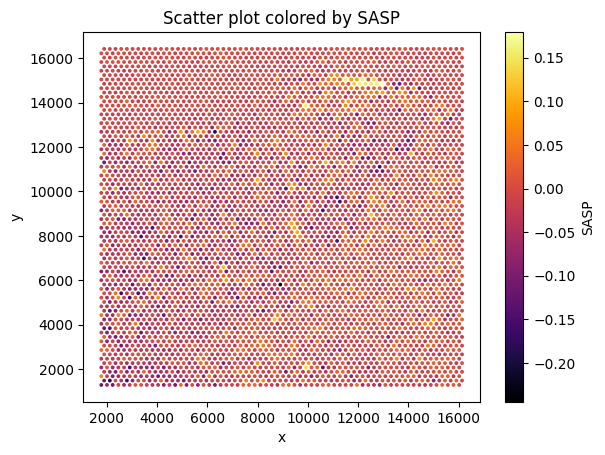

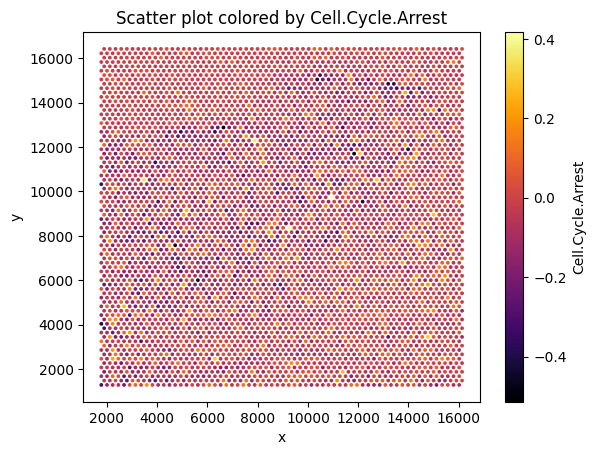

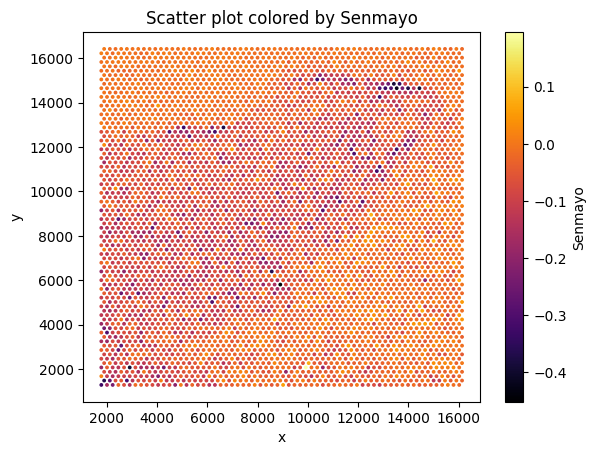

In [9]:
# Plot by biomarker
# Columns to use for coloring
color_columns = ['San.Diego.TMC', 'Resistance.to.Apoptosis',
                 'Fridman', 'Activated.p53.Targets', 'DDR', 'SASP', 'Cell.Cycle.Arrest', 'Senmayo']

# Create a series of scatter plots
for color_col in color_columns:
    plt.figure()
    plt.scatter(df['x'], df['y'], c=df[color_col], cmap='inferno', s=3)
    plt.colorbar(label=color_col)
    plt.title(f'Scatter plot colored by {color_col}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()